In [1]:
%load_ext autoreload
%autoreload 2

In [64]:
import matplotlib.pyplot as plt
import datetime

In [2]:
from pathlib import Path
import numpy as np
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.thgem_tpc.purity_workflow import map_purity_extraction, plot_gas_purity_evolution
from RaTag.thgem_tpc.drift_workflow import map_drift_physics

# Run bootstrap and enrichment

In [3]:
path_config = Path(r"C:\Users\lab\Documents\Pablo\RaTag\configs\run_circulation.yaml")
run = bootstrap_from_config(path_config)
run = map_drift_physics(run)

Found 5 directories in circulation_data
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0200_Anode1000_batch1 with 5000 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0200_Anode1000_batch2 with 5000 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0200_Anode1000_batch3 with 100 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0200_Anode1000_batch4 with 500 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0210_Anode1010 with 20 waveforms.
  → Bootstrapped 5 PMT Sets and 5 Alpha Sets. (Multi-Isotope: True)
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0200_Anode1000_batch1'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0200_Anode1000_batch1'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0200_Anode1000_batch1'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0200_Anode1000_batch2'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0200_Anode1000_batch2'
  📂 Cac

# S2 width and position tracking

In [49]:
from RaTag.io.file_ops import parse_wfm_timestamp

In [10]:
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
from scipy.ndimage import maximum_filter1d
from RaTag.io.file_ops import iter_waveforms
from dataclasses import replace

def find_s2(wf):
    # 1. Base parameters & preprocessing
    s2_threshold = 150
    t_min_s2 = -2.0
    s2_fraction = 0.2
    s2_min = 0.5
    s2_max = 50.0  

    is_clipped = np.any(wf.v >= s2_threshold, axis=1)
    has_no_clips = ~is_clipped

    wf_sub = subtract_pedestal(wf, n_points=200)
    v_envelope = maximum_filter1d(wf_sub.v, size=1000, axis=1)
    wf_smooth = replace(wf_sub, v=v_envelope, nframes=wf_sub.nframes)

    mask = wf_smooth.t > t_min_s2
    t_sliced = wf_smooth.t[mask]
    v_sliced = wf_smooth.v[:, mask] if wf_smooth.ff else wf_smooth.v[mask][np.newaxis, :]

    # 2. Anchor to Global Maximum & Find Boundaries
    peak_idx = np.argmax(v_sliced, axis=1)
    peak_heights = v_sliced[np.arange(len(v_sliced)), peak_idx]
    peak_times = t_sliced[peak_idx]
        
    dynamic_thresh = (peak_heights * s2_fraction)[:, np.newaxis]
    below_thresh = v_sliced <= dynamic_thresh
    idx_2d = np.arange(v_sliced.shape[1])[np.newaxis, :]

    # Left boundary search
    left_mask = idx_2d <= peak_idx[:, np.newaxis]
    valid_left = below_thresh & left_mask
    first_below_left_rev = np.argmax(np.fliplr(valid_left), axis=1)
    start_time = t_sliced[np.clip(v_sliced.shape[1] - 1 - first_below_left_rev, 0, v_sliced.shape[1] - 1)]

    # Right boundary search
    right_mask = idx_2d >= peak_idx[:, np.newaxis]
    valid_right = below_thresh & right_mask
    last_below_right = np.argmax(valid_right, axis=1)
    end_time = t_sliced[np.clip(last_below_right - 1, 0, v_sliced.shape[1] - 1)]

    # 3. Area Integration
    dt = wf_sub.t[1] - wf_sub.t[0]
    t_2d = wf_sub.t[np.newaxis, :]
    s2_mask = (t_2d >= start_time[:, np.newaxis]) & (t_2d <= end_time[:, np.newaxis])
    s2_areas = np.sum(wf_sub.v * s2_mask, axis=1) * dt

    # 4. COMBINE ALL CUTS VECTORIALLY
    # Check if left and right searches successfully found valid boundaries (did not default entirely)
    has_valid_left = np.any(valid_left, axis=1)
    has_valid_right = np.any(valid_right, axis=1)

    # Assemble the final acceptance filter mask
    accepted_events = (
        has_no_clips & 
        has_valid_left & 
        has_valid_right & 
        (s2_areas > s2_min) & 
        (s2_areas < s2_max)
    )

    filtered_areas = s2_areas[accepted_events]
    filtered_peak_times = peak_times[accepted_events]
    filtered_start_times = start_time[accepted_events]
    filtered_end_times = end_time[accepted_events]
    return {
        'areas': filtered_areas,
        'peak_times': filtered_peak_times,
        'start_times': filtered_start_times,
        'end_times': filtered_end_times,
        'accepted_events': accepted_events
    }


In [7]:
set0 = run.sets[0]
set0

SetPmt state:
  source_dir = \\Lab104con\K\AXO-RITA\raw_data\circulation_data\FieldScan_Gate0200_Anode1000_batch1
  filenames = <5000 files, 4935000 waveforms, FastFrame(987 frames/file)>
  multiiso = True
  ff = True
  nframes = 987
  gate = 200
  anode = 1000
  drift_field = 416.667
  EL_field = 20000.0
  red_drift_field = 1.709
  red_EL_field = 82.011
  speed_drift = 1.506
  time_drift = 3.188
  n_areas_recoil = 9204

  Missing:
    target_isotope, sampling_rate, diffusion_coefficient, baseline_median, baseline_std, t_s1, t_s1_std, t_s2_start, t_s2_start_std, t_s2_end, t_s2_end_std, filtered_drift_time, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success, s2_background_bound

In [12]:

batch_size = 10
total_files = 5000

batch_median_starts = []
batch_median_ends = []
batch_median_peaks = []

# Loop through file indices in steps of 10
for start_idx in range(0, total_files, batch_size):
    current_batch_areas = []
    current_batch_peaks = []
    current_batch_starts = []
    current_batch_ends = []
    
    # Consume exactly 10 files using the updated explicit start index
    for wf in iter_waveforms(set0, max_files=batch_size, start_file=start_idx, show_progress=True):
        res_dict = find_s2(wf)
        current_batch_areas.append(res_dict['areas'])
        current_batch_peaks.append(res_dict['peak_times'])
        current_batch_starts.append(res_dict['start_times'])
        current_batch_ends.append(res_dict['end_times'])
    
    # Skip empty batches if we hit the end of the dataset early
    if not current_batch_areas or all(len(a) == 0 for a in current_batch_areas):
        continue
        
    # Concatenate frames for this 10-file block (~9,880 frames total)
    b_areas = np.concatenate(current_batch_areas)
    b_peaks = np.concatenate(current_batch_peaks)
    b_starts = np.concatenate(current_batch_starts)
    b_ends = np.concatenate(current_batch_ends)
    
    # Guard against empty filtered results after cuts
    if len(b_starts) > 0:
        batch_median_starts.append(np.median(b_starts))
        batch_median_ends.append(np.median(b_ends))
        batch_median_peaks.append(np.median(b_peaks))
    else:
        batch_median_starts.append(np.nan)
        batch_median_ends.append(np.nan)
        batch_median_peaks.append(np.nan)

# Convert tracked block metrics to final arrays for plotting your time evolution
batch_median_starts = np.array(batch_median_starts)
batch_median_ends = np.array(batch_median_ends)
batch_median_peaks = np.array(batch_median_peaks)

  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch1: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000

In [13]:
path_out = Path(r"\\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\timing_batch1.npz")
with open(path_out, 'wb') as f:
    np.savez_compressed(f, starts=batch_median_starts, ends=batch_median_ends, peaks=batch_median_peaks)

In [14]:
for i, set in enumerate(run.sets[1:]):
        
    batch_size = 10
    total_files = len(set.filenames)

    batch_median_starts = []
    batch_median_ends = []
    batch_median_peaks = []

    # Loop through file indices in steps of 10
    for start_idx in range(0, total_files, batch_size):
        current_batch_areas = []
        current_batch_peaks = []
        current_batch_starts = []
        current_batch_ends = []
        
        # Consume exactly 10 files using the updated explicit start index
        for wf in iter_waveforms(set, max_files=batch_size, start_file=start_idx, show_progress=True):
            res_dict = find_s2(wf)
            current_batch_areas.append(res_dict['areas'])
            current_batch_peaks.append(res_dict['peak_times'])
            current_batch_starts.append(res_dict['start_times'])
            current_batch_ends.append(res_dict['end_times'])
        
        # Skip empty batches if we hit the end of the dataset early
        if not current_batch_areas or all(len(a) == 0 for a in current_batch_areas):
            continue
            
        # Concatenate frames for this 10-file block (~9,880 frames total)
        b_areas = np.concatenate(current_batch_areas)
        b_peaks = np.concatenate(current_batch_peaks)
        b_starts = np.concatenate(current_batch_starts)
        b_ends = np.concatenate(current_batch_ends)
        
        # Guard against empty filtered results after cuts
        if len(b_starts) > 0:
            batch_median_starts.append(np.median(b_starts))
            batch_median_ends.append(np.median(b_ends))
            batch_median_peaks.append(np.median(b_peaks))
        else:
            batch_median_starts.append(np.nan)
            batch_median_ends.append(np.nan)
            batch_median_peaks.append(np.nan)

    # Convert tracked block metrics to final arrays for plotting your time evolution
    batch_median_starts = np.array(batch_median_starts)
    batch_median_ends = np.array(batch_median_ends)
    batch_median_peaks = np.array(batch_median_peaks)

    path_out = Path(rf"\\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\timing_batch{i+2}.npz")
    with open(path_out, 'wb') as f:
        np.savez_compressed(f, starts=batch_median_starts, ends=batch_median_ends, peaks=batch_median_peaks)



  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000_batch2: 10/10 (100.0%) | ETA: 00:00   
  Iterating FieldScan_Gate0200_Anode1000

In [46]:
starts, ends, peaks = [], [], []
path_dir = Path(rf"\\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics")
files = sorted(path_dir.glob("timing_batch*.npz"))
for f in files:
    with np.load(f) as data:
        starts.append(data['starts'])
        ends.append(data['ends'])
        peaks.append(data['peaks'])

starts = np.concatenate(starts)
ends = np.concatenate(ends)
peaks = np.concatenate(peaks)

width = ends - starts

In [67]:
tstamps = []
for s in run.sets:
    tsta = [parse_wfm_timestamp(s.f) for s.f in s.filenames[::10]]
    tstamps.extend(tsta)
dtime = [datetime.datetime.fromtimestamp(ts) for ts in tstamps[:-2]]
dtime[0]

datetime.datetime(2026, 7, 16, 18, 5, 22)

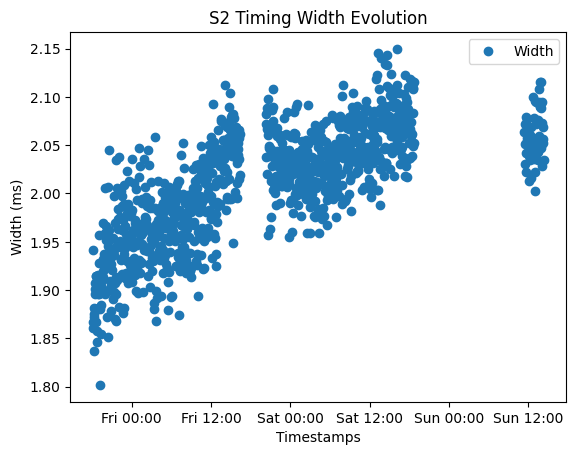

In [72]:
plt.plot(dtime, width[:-2], 'o', label='Width')
plt.gca().set(title='S2 Timing Width Evolution', xlabel='Timestamps', ylabel='Width (ms)')
# plt.plot(peaks[:-2], 'o', label='Peak')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%a %H:%M'))
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())
plt.legend()

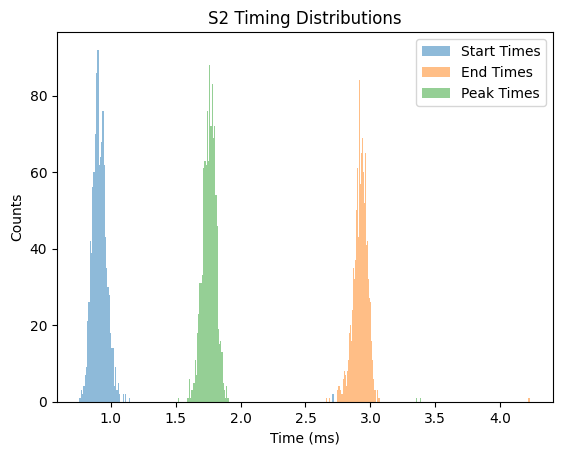

In [45]:
plt.hist(starts, bins=200, alpha=0.5, label='Start Times')
plt.hist(ends, bins=200, alpha=0.5, label='End Times')
plt.hist(peaks, bins=200, alpha=0.5, label='Peak Times');
plt.gca().set(title='S2 Timing Distributions', xlabel='Time (ms)', ylabel='Counts')
plt.legend()

# Purity workflow

In [189]:
run = map_purity_extraction(run, max_frames = 1_000_000, force=True)


EXTRACTING PURITY METRICS: RUN_C
  Iterating FieldScan_Gate0200_Anode1000: 136/137 (99.3%) | ETA: 00:09     FieldScan_Gate0200_Anode1000: 905/135219 purity events logged.
  ✓ FieldScan_Gate0200_Anode1000: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0200_Anode1000_batch1: 1013/1014 (99.9%) | ETA: 00:09       FieldScan_Gate0200_Anode1000_batch1: 9204/1000818 purity events logged.
  ✓ FieldScan_Gate0200_Anode1000_batch1: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0200_Anode1000_batch2: 1013/1014 (99.9%) | ETA: 00:09       FieldScan_Gate0200_Anode1000_batch2: 6957/1000818 purity events logged.
  ✓ FieldScan_Gate0200_Anode1000_batch2: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0200_Anode1000_batch3: 99/100 (99.0%) | ETA: 00:09     FieldScan_Gate0200_Anode1000_batch3: 692/98700 purity events logged.
  ✓ FieldScan_Gate0200_Anode1000_batch3: Computed 'n_areas_recoil' and stored metadata


In [ ]:
path = r'\\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_batch2_purity_metrics.npz'
npzfile = np.load(path)
npzfile['timestamps']

array([1.78445191e+09, 1.78445191e+09, 1.78445191e+09, 1.78445191e+09,
       1.78445191e+09, 1.78445191e+09, 1.78445191e+09, 1.78445191e+09,
       1.78445191e+09, 1.78445193e+09, 1.78445193e+09, 1.78445193e+09,
       1.78445193e+09, 1.78445193e+09, 1.78445193e+09, 1.78445193e+09])

In [21]:
path = r'\\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_batch2_purity_metrics.npz'
npzfile = np.load(path)
npzfile['timestamps']

array([1.78430861e+09, 1.78430861e+09, 1.78430861e+09, 1.78430862e+09,
       1.78430862e+09, 1.78430862e+09, 1.78430862e+09, 1.78430862e+09,
       1.78430862e+09])

Aggregating Purity data for Run RUN_C...
  Loading purity_metrics arrays from: \\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_purity_metrics.npz
  Loading purity_metrics arrays from: \\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_batch1_purity_metrics.npz
  Loading purity_metrics arrays from: \\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_batch2_purity_metrics.npz
  Loading purity_metrics arrays from: \\Lab104con\K\AXO-RITA\processed\circulation_data\purity_metrics\FieldScan_Gate0200_Anode1000_batch3_purity_metrics.npz


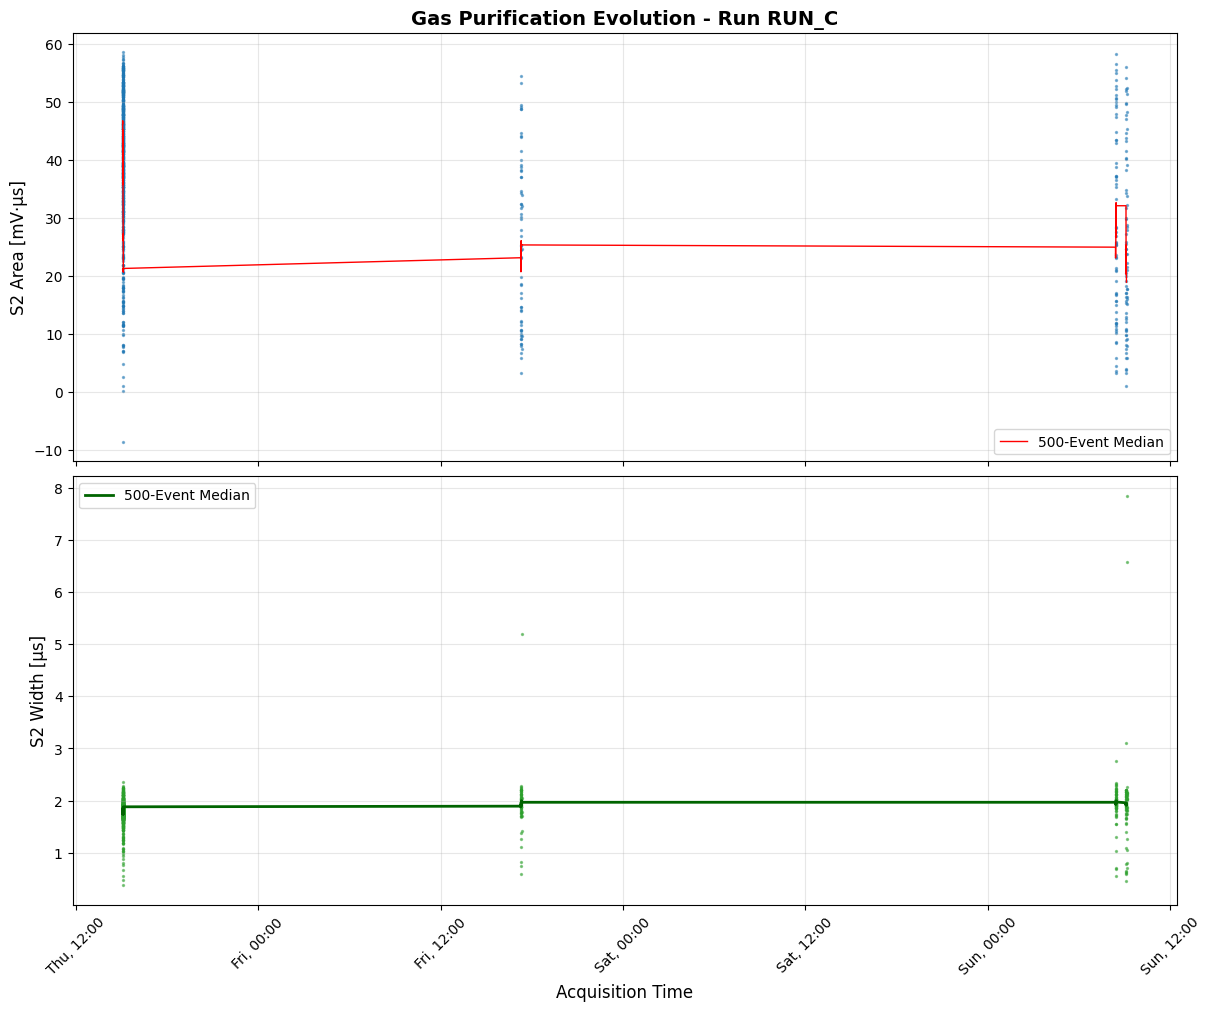

In [30]:
df = plot_gas_purity_evolution(run)

In [29]:
df

,Time,S2_Area,S2_Width
169,2026-07-16 15:05:22,35.346116,1.4388
122,2026-07-16 15:05:22,48.865547,2.0390
123,2026-07-16 15:05:22,36.860145,1.6406
124,2026-07-16 15:05:22,46.229998,1.7674
125,2026-07-16 15:05:22,51.322200,1.8192
...,...,...,...
67,2026-07-19 09:07:52,22.226122,2.0108
69,2026-07-19 09:07:52,17.740595,2.0466
68,2026-07-19 09:07:52,15.199467,1.2666
70,2026-07-19 09:07:52,17.786254,1.0454


In [39]:
from RaTag.io.file_ops import load_wfm, iter_waveforms
from RaTag.plotting import plot_waveform

(<Axes: title={'center': 'Waveform, File CH3, frame 649 of 987'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
 np.float64(11.999998614192007))

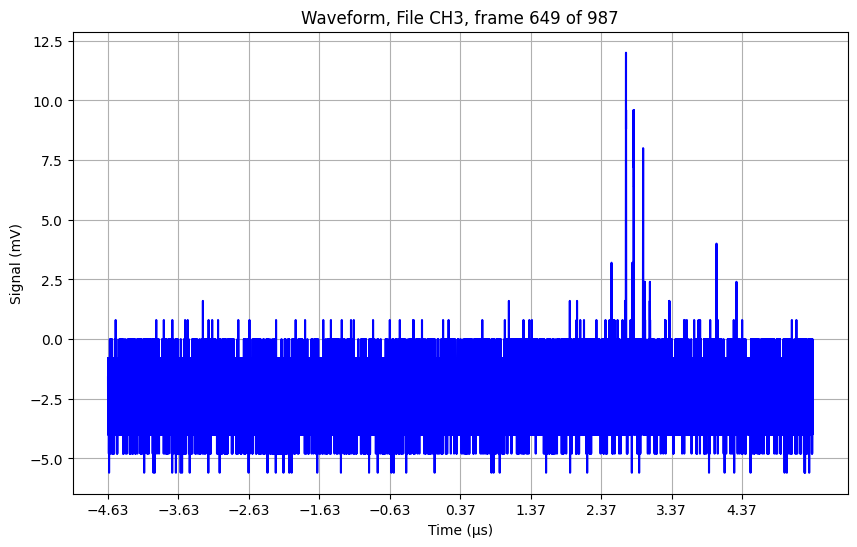

In [188]:
set3 = run.sets[0]
# wf = next(iter_waveforms(set3, ))
plot_waveform(wf, )